In [ ]:
import sys
import os

print("Current working directory:", os.getcwd())
print("Contents of /content:", os.listdir("/content"))

sys.path.insert(0, "/content/fairness-folktables/src")

print("Python path:")
for p in sys.path[:5]:
    print(p)


Current working directory: /content
Contents of /content: ['.config', 'data', '.ipynb_checkpoints', 'fairness-folktables', 'sample_data']
Python path:
/content/fairness-folktables/src
/content/fairness-folktables/src
/content
/env/python
/usr/lib/python312.zip


In [ ]:
import os
os.listdir()


['.config', 'data', '.ipynb_checkpoints', 'fairness-folktables', 'sample_data']

In [ ]:
os.listdir('/content/fairness-folktables')


['.ipynb_checkpoints', 'src']

In [ ]:
import sys
sys.path.append('/content/fairness-folktables')


In [ ]:
import src
print("src imported successfully")


src imported successfully


In [ ]:
pip install folktables

In [ ]:
from src.data import load_data
from src.fairness_utils import evaluate_model, equal_opportunity

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from src.fairness_utils import evaluate_model, equal_opportunity


In [ ]:
X, y, sex = load_data("CA")

X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
    X, y, sex, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

# Re-train baseline Logistic Regression
baseline_model = LogisticRegression(max_iter=2000)
baseline_model.fit(X_train_scaled, y_train)

baseline_results = evaluate_model(
    baseline_model, X_test_scaled, y_test, s_test
)

baseline_results


{'accuracy': 0.785434412265758,
 'eo': {1: np.float64(0.7644404332129964), 2: np.float64(0.6447354852016087)},
 'eo_gap': np.float64(0.11970494801138765),
 'dp': {1: np.float64(0.4675857170530122), 2: np.float64(0.30790593666594535)},
 'dp_gap': np.float64(0.15967978038706687)}

In [ ]:
# Gradient Boosting model
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_results = evaluate_model(
    gb_model, X_test, y_test, s_test
)

gb_results


{'accuracy': 0.8140034071550255,
 'eo': {1: np.float64(0.7908914190502638), 2: np.float64(0.7197071259152316)},
 'eo_gap': np.float64(0.07118429313503227),
 'dp': {1: np.float64(0.46561632336798603), 2: np.float64(0.3295462742552117)},
 'dp_gap': np.float64(0.13607004911277432)}

In [ ]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["Baseline (LR)", "Improved (GB)"],
    "Accuracy": [baseline_results["accuracy"], gb_results["accuracy"]],
    "EO Gap": [baseline_results["eo_gap"], gb_results["eo_gap"]],
    "DP Gap": [baseline_results["dp_gap"], gb_results["dp_gap"]]
})

comparison


,Model,Accuracy,EO Gap,DP Gap
0,Baseline (LR),0.785434,0.119705,0.15968
1,Improved (GB),0.814003,0.071184,0.13607


In [ ]:
probs = baseline_model.predict_proba(X_test_scaled)[:, 1]

mitigated_preds = []
for i in range(len(s_test)):
    threshold = 0.4 if s_test[i] == 2 else 0.5
    mitigated_preds.append(1 if probs[i] >= threshold else 0)

mitigated_preds = np.array(mitigated_preds)

new_tprs = equal_opportunity(y_test, mitigated_preds, s_test)

print("EO Gap after mitigation:",
      abs(new_tprs[1] - new_tprs[2]))
print("Accuracy after mitigation:",
      accuracy_score(y_test, mitigated_preds))


EO Gap after mitigation: 0.0017303166821105442
Accuracy after mitigation: 0.7817206132879047


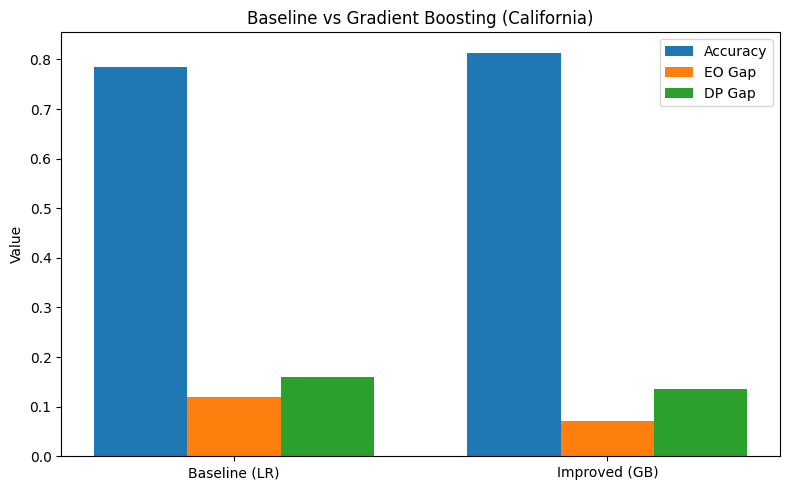

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Baseline (LR)", "Improved (GB)"]
accuracy = [baseline_results["accuracy"], gb_results["accuracy"]]
eo_gap = [baseline_results["eo_gap"], gb_results["eo_gap"]]
dp_gap = [baseline_results["dp_gap"], gb_results["dp_gap"]]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, accuracy, width, label="Accuracy")
plt.bar(x, eo_gap, width, label="EO Gap")
plt.bar(x + width, dp_gap, width, label="DP Gap")

plt.xticks(x, models)
plt.ylabel("Value")
plt.title("Baseline vs Gradient Boosting (California)")
plt.legend()
plt.tight_layout()
plt.show()
